In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from keras_tuner.tuners import BayesianOptimization

from datetime import datetime
import pickle

## LOADING DATASET

In [9]:
# LOADING DATASET

PATH_TRAINING_A = '/Users/pia/Documents/Cartography/Masterarbeit/line-displacement/data/preprocessing/normalized/normalized_local_newsyn2_original.npy'
lines_a_noisy = np.load(PATH_TRAINING_A)

train_norm, temp = train_test_split(lines_a_noisy, test_size=0.4, random_state=42)  # 40% for val+test
val_norm, test_norm = train_test_split(temp, test_size=0.25, random_state=42)   

print(f'Train Shape {train_norm.shape}, Val Shape {val_norm.shape}, Test Shape {test_norm.shape}')

Train Shape (30438, 64, 2), Val Shape (15219, 64, 2), Test Shape (5074, 64, 2)


In [11]:
# SAVING TEST DATASET
with open(f'/Users/pia/Documents/Cartography/Masterarbeit/line-displacement/data/final_dataset/sequence/ae_test_dataset_newsyn2.pkl', 'wb') as f:
    pickle.dump(test_norm, f)

## BUILDING AUTOENCODER ARCHITECTURE

In [12]:
#AE ARCHITECTURE

timesteps = 64
features = 2
latent_dim = 32 

inputs = Input(shape=(timesteps, features))

# ENCODER (depth = 1, bidirectional)
x = Bidirectional(LSTM(128))(inputs)
encoded = Dense(latent_dim, activation='linear')(x)

# DECODER
x = RepeatVector(timesteps)(encoded)
x = LSTM(64, return_sequences=True)(x)
decoded = TimeDistributed(Dense(features))(x)

lstm_autoencoder = Model(inputs, decoded)
#lstm_autoencoder.summary()


2026-01-20 12:18:34.048436: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-01-20 12:18:34.048672: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-20 12:18:34.048687: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-01-20 12:18:34.048716: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-20 12:18:34.048731: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## MODEL TRAINING

In [22]:
#TRAINING SETUP 

description = 'mse_local_finetuned_bidrectional_newsyn2'
epochs = 150
batch_size = 32
loss = 'mse' #huber, 'mse', mae
optimizer=tf.keras.optimizers.Adam(learning_rate=5.16e-3)

early_stop = EarlyStopping(
    monitor='val_loss',     # what to watch
    patience=20,            # epochs to wait for improvement
    restore_best_weights=True   
)

log_dir = "/Users/pia/Documents/Cartography/Masterarbeit/line-displacement/checkpoints/autoencoder/logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# metrics: things to be observed, loss: what is actually used for learning.  ,
lstm_autoencoder.compile(optimizer=optimizer, loss=loss, metrics=['accuracy','mse', 'mae'])

In [ ]:
#TRAINING

timestamp = datetime.now().strftime('%d%m_%H%M')

history = lstm_autoencoder.fit(
    train_norm, train_norm,
    validation_data=(val_norm, val_norm),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=[early_stop, tensorboard_callback]
)


Epoch 1/150
952/952 ━━━━━━━━━━━━━━━━━━━━ 100s 101ms/step - accuracy: 0.9875 - loss: 1.2882e-04 - mae: 0.0070 - mse: 1.2882e-04 - val_accuracy: 0.9868 - val_loss: 7.7448e-05 - val_mae: 0.0065 - val_mse: 7.7448e-05
Epoch 2/150
952/952 ━━━━━━━━━━━━━━━━━━━━ 99s 104ms/step - accuracy: 0.9895 - loss: 7.7771e-05 - mae: 0.0062 - mse: 7.7771e-05 - val_accuracy: 0.9882 - val_loss: 7.6883e-05 - val_mae: 0.0069 - val_mse: 7.6883e-05
Epoch 3/150
952/952 ━━━━━━━━━━━━━━━━━━━━ 95s 100ms/step - accuracy: 0.9871 - loss: 2.1389e-04 - mae: 0.0079 - mse: 2.1389e-04 - val_accuracy: 0.9787 - val_loss: 2.8374e-04 - val_mae: 0.0121 - val_mse: 2.8374e-04
Epoch 4/150
952/952 ━━━━━━━━━━━━━━━━━━━━ 99s 104ms/step - accuracy: 0.9851 - loss: 1.4001e-04 - mae: 0.0083 - mse: 1.4001e-04 - val_accuracy: 0.9876 - val_loss: 8.7647e-05 - val_mae: 0.0067 - val_mse: 8.7647e-05
Epoch 5/150
952/952 ━━━━━━━━━━━━━━━━━━━━ 91s 95ms/step - accuracy: 0.9890 - loss: 7.2397e-05 - mae: 0.0061 - mse: 7.2397e-05 - val_accuracy: 0.9908 - v

In [19]:
%reload_ext tensorboard
%tensorboard --logdir /Users/pia/Documents/Cartography/Masterarbeit/line-displacement/checkpoints/autoencoder/logs

Reusing TensorBoard on port 6008 (pid 20247), started 1:00:52 ago. (Use '!kill 20247' to kill it.)

In [20]:
# TRAINING HISTORY 

def plot_history(history, epochs, batch_size, saving_img=False):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='#143642')

    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='#EC9A29')

    plt.xlabel('Epochs', fontdict={'family': 'serif', 'size': 10})
    plt.ylabel('Loss', fontdict={'family': 'serif', 'size': 10})
    plt.legend(prop={'family': 'serif', 'size': 10})
    plt.title(f'Training Loss LSTM AE {epochs} Epochs', fontdict={'family': 'serif', 'size': 14})
    plt.xticks(fontsize=10, family='serif')
    plt.yticks(fontsize=10, family='serif')
    plt.grid()
    
    if saving_img:
        # save figure 
        save_path = f'/Users/pia/Documents/Cartography/Masterarbeit/line-displacement/checkpoints/autoencoder/history/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

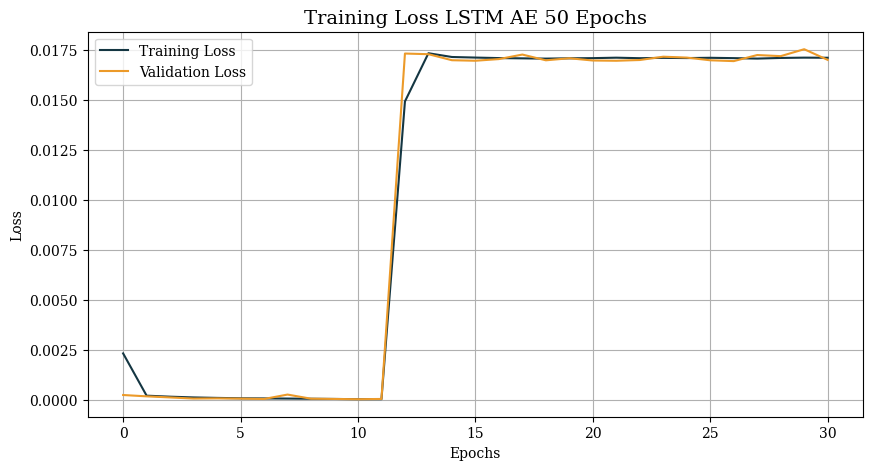

In [21]:
plot_history(history, epochs, batch_size, saving_img=False)

In [ ]:
# SAVING MODEL, WEIGHTS, HISTORY
lstm_autoencoder.save(f'/Users/pia/Documents/Cartography/Masterarbeit/line-displacement/checkpoints/autoencoder/model/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.keras')
lstm_autoencoder.save_weights(f'/Users/pia/Documents/Cartography/Masterarbeit/line-displacement/checkpoints/autoencoder/weights/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.weights.h5')
np.save(f'/Users/pia/Documents/Cartography/Masterarbeit/line-displacement/checkpoints/autoencoder/history/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.npy', history.history)

## POST TRAINING

In [ ]:
epochs=150
batch_size=32

In [ ]:
def plot_history(history, epochs, batch_size):
    plt.figure(figsize=(10, 5))
    plt.plot(history['loss'], label='Training Loss', color='#143642')

    if 'val_loss' in history:
        plt.plot(history['val_loss'], label='Validation Loss', color='#EC9A29')

    plt.xlabel('Epochs', fontdict={'family': 'serif', 'size': 10})
    plt.ylabel('Loss', fontdict={'family': 'serif', 'size': 10})
    plt.legend(prop={'family': 'serif', 'size': 10})
    plt.title(f'Training Loss LSTM AE {epochs} Epochs', fontdict={'family': 'serif', 'size': 14})
    plt.xticks(fontsize=10, family='serif')
    plt.yticks(fontsize=10, family='serif')
    plt.grid()
    
    # save figure 
    #save_path = f'../checkpoints/autoencoder/history/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.png'
    save_path = f'../checkpoints/autoencoder/history/bestModel_{batch_size}_batches_{epochs}_epochs.png'
    #plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [ ]:
# LOADING MODEL AND HISTORY

#lstm_autoencoder = tf.keras.models.load_model(f'../checkpoints/autoencoder/model/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.keras')
lstm_autoencoder = tf.keras.models.load_model(f'../checkpoints/autoencoder/model/2312_bestModel_32_batches_150_epochs.keras')
history = np.load(
    '../checkpoints/autoencoder/history/2312_bestModel_32_batches_150_epochs.npy',
    allow_pickle=True
).item()
#history
plot_history(history, epochs, batch_size)

In [ ]:
reconstructed = lstm_autoencoder.predict(test_norm)

In [ ]:
# SAVING PREDICTION 

#with open(f'../data/results/lstm_autoencoder/{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs_predictions.pkl', 'wb') as f:
with open(f'../data/results/lstm_autoencoder/2312_bestModel_{batch_size}_batches_{epochs}_epochs_predictions.pkl', 'wb') as f:
    pickle.dump(reconstructed, f)

In [ ]:
# PLOT PREDICTION
for i in range(1000,1036):
    plt.figure(figsize=(6, 10))

    plt.plot(test_norm[i,:,0], test_norm[i,:,1], color='#143642',  linestyle='--', label='Original')
    plt.plot(reconstructed[i,:,0], reconstructed[i,:,1], color='#EC9A29', label='Reconstructed')


    plt.xlabel('X', fontdict={'family': 'serif', 'size': 10})
    plt.ylabel('Y', fontdict={'family': 'serif', 'size': 10})

    plt.legend(prop={'family': 'serif', 'size': 10})
    plt.xticks(fontsize=10, family='serif')
    plt.yticks(fontsize=10, family='serif')
    plt.axis('equal')
    plt.grid(True)
    plt.title(f'LSTM AE Prediction - Line {i}', fontdict={'family': 'serif', 'size': 14})    
    
    # save figure 
    #save_path = f'../figures/predictions/prediction_line_{i}_{timestamp}_{description}_{batch_size}_batches_{epochs}_epochs.png'
    #plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


## HYPERPARAMETER OPTIMIZATION

In [ ]:
num_points = 64
coordinates = 2

def build_model(hp):
    # Latent dimension
    #latent_dim = hp.Choice('latent_dim', [8, 16, 32])
    
    # Depth (1,2,3 LSTM layers)
    depth = hp.Choice('depth', [1, 2, 3])
    
    # Hidden size options
    hidden_sizes = [8, 32, 64, 128]
    
    # Encoder LSTM units per layer
    enc_units = [hp.Choice(f'enc_lstm{i+1}', hidden_sizes) for i in range(depth)]
    
    # Decoder LSTM units per layer (mirror encoder)
    dec_units = [hp.Choice(f'dec_lstm{i+1}', hidden_sizes) for i in range(depth)]
    
    # Learning rate
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    
    inputs = Input(shape=(num_points, coordinates))
    
    # ENCODER
    x = inputs
    for units in enc_units[:-1]:
        x = LSTM(units, return_sequences=True)(x)
    x = LSTM(enc_units[-1])(x)  # last layer without return_sequences
    
    #encoded = x
    # LATENT BOTTLE TBC
    latent = hp.Choice('latent_dim', [8, 16, 32])
    encoded = Dense(latent, activation='linear')(x)
    
    # DECODER
    x = RepeatVector(num_points)(encoded)
    for units in dec_units[:-1]:
        x = LSTM(units, return_sequences=True)(x)
    x = LSTM(dec_units[-1], return_sequences=True)(x)  # last layer returns sequences
    outputs = TimeDistributed(Dense(coordinates))(x)
    
    model = Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='mse',
        metrics=['mse', 'mae']
    )
    
    return model


In [ ]:
tuner = BayesianOptimization(
    hypermodel=build_model,
    objective='val_loss',
    max_trials=20,          
    executions_per_trial=1,  
    directory= '../checkpoints/autoencoder/', 
    project_name='tuner_results'
)

In [ ]:
tuner.search(
    train_norm, train_norm,
    validation_data=(val_norm, val_norm),
    epochs=100,
    batch_size=32, #64
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]
)

In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.get_best_models(1)[0]

print('Best hyperparameters:')
for p, v in best_hp.values.items():
    print(p, '=', v)


In [ ]:
history = best_model.fit(
    train_norm, train_norm,
    validation_data=(val_norm, val_norm),
    epochs=150,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)]
)


In [ ]:
best_model.save(f'../checkpoints/autoencoder/model/bestModel.keras')
best_model.save_weights(f'../checkpoints/autoencoder/weights/bestModel.weights.h5')
np.save(f'../checkpoints/autoencoder/history/bestModel.npy', history.history)

In [ ]:
best_model.summary()